## 06_ablation_study_updated.ipynb

Performs the component-wise ablation analysis of:

*   surrogate-assisted evaluation
*   safety-aware fitness evaluation,
*   selective high-fidelity validation







In [ ]:
# CELL 1 - Setup

from google.colab import drive
drive.mount('/content/drive')

# Update this path only if your project folder is different.
PROJECT_DIR = "/content/drive/MyDrive/Research/glycemic-hybrid-ga"
%cd $PROJECT_DIR

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

METHOD_NAMES = {
    "ga_only": "GA",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "Surrogate-GA",
    "hybrid": "Hybrid",
}

METHOD_ORDER = ["GA", "GA+Rules", "Surrogate-GA", "Hybrid"]

# Consistent colors with manuscript figures.
COLORS = {
    "GA": "#1f77b4",
    "GA+Rules": "#ff7f0e",
    "Surrogate-GA": "#2ca02c",
    "Hybrid": "#d62728",
}

print("[OK] Setup completed.")


Mounted at /content/drive
/content/drive/MyDrive/Research/glycemic-hybrid-ga
[OK] Setup completed.


In [ ]:
# CELL 2 - Load final high-fidelity results

candidate_paths = [
    "outputs/results/summary_all_with_reduction.csv",
    "outputs/results/summary_all.csv",
]

summary_path = None
for path in candidate_paths:
    if os.path.exists(path):
        summary_path = path
        break

if summary_path is None:
    raise FileNotFoundError(
        "No summary file found. Please run the main experiment notebook first. "
        "Expected one of: outputs/results/summary_all_with_reduction.csv "
        "or outputs/results/summary_all.csv"
    )

df = pd.read_csv(summary_path)

required_cols = [
    "Scenario", "Method", "Fitness", "BestTrueFitness", "TIR", "TBR", "TAR",
    "Gmin", "Gmax", "MeanG", "AUCmean", "AUCregret", "SimCalls"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in {summary_path}: {missing}")

df["MethodLabel"] = df["Method"].map(METHOD_NAMES)

if df["MethodLabel"].isna().any():
    unknown = sorted(df.loc[df["MethodLabel"].isna(), "Method"].unique())
    raise ValueError(f"Unknown method names found: {unknown}")

df["MethodLabel"] = pd.Categorical(
    df["MethodLabel"],
    categories=METHOD_ORDER,
    ordered=True
)

df = df.sort_values(["Scenario", "MethodLabel"]).reset_index(drop=True)

if "Backend" in df.columns:
    backends = sorted(df["Backend"].dropna().unique())
    print("[INFO] Backend(s) detected:", backends)
    if any(str(b).lower() not in ["simglucose", "uva/padova", "uva_padova"] for b in backends):
        print("[WARNING] This file may contain non-high-fidelity or simplified results.")
else:
    print("[INFO] No Backend column found. Proceeding with loaded final summary file.")

print("[OK] Loaded:", summary_path)
display(df)


## Component-level ablation definition

The four compared methods are interpreted as component ablations:

| Method | GA Search | Safety-Aware Fitness | Surrogate Model | Selective True Evaluation |
|---|---:|---:|---:|---:|
| GA | Yes | No | No | No |
| GA+Rules | Yes | Yes | No | No |
| Surrogate-GA | Yes | No | Yes | Yes |
| Hybrid | Yes | Yes | Yes | Yes |

This makes the ablation coherent with the implementation:
- `GA` isolates the evolutionary optimizer,
- `GA+Rules` isolates the safety-aware penalty contribution,
- `Surrogate-GA` isolates surrogate-based simulation reduction,
- `Hybrid` combines safety-aware evaluation and surrogate-assisted selective validation.


In [ ]:
# CELL 3 - Construct ablation table

component_flags = {
    "GA": {
        "GA_Search": 1,
        "Safety_Aware_Fitness": 0,
        "Surrogate_Model": 0,
        "Selective_True_Evaluation": 0,
        "ComponentSetting": "GA search only"
    },
    "GA+Rules": {
        "GA_Search": 1,
        "Safety_Aware_Fitness": 1,
        "Surrogate_Model": 0,
        "Selective_True_Evaluation": 0,
        "ComponentSetting": "GA + safety-aware fitness"
    },
    "Surrogate-GA": {
        "GA_Search": 1,
        "Safety_Aware_Fitness": 0,
        "Surrogate_Model": 1,
        "Selective_True_Evaluation": 1,
        "ComponentSetting": "GA + surrogate-assisted selective evaluation"
    },
    "Hybrid": {
        "GA_Search": 1,
        "Safety_Aware_Fitness": 1,
        "Surrogate_Model": 1,
        "Selective_True_Evaluation": 1,
        "ComponentSetting": "GA + safety-aware surrogate-assisted selective evaluation"
    },
}

ablation = df.copy()
for col in ["GA_Search", "Safety_Aware_Fitness", "Surrogate_Model", "Selective_True_Evaluation", "ComponentSetting"]:
    ablation[col] = ablation["MethodLabel"].astype(str).map(
        {k: v[col] for k, v in component_flags.items()}
    )

ablation_cols = [
    "Scenario", "MethodLabel", "ComponentSetting",
    "GA_Search", "Safety_Aware_Fitness", "Surrogate_Model", "Selective_True_Evaluation",
    "Fitness", "BestTrueFitness", "TIR", "TBR", "TAR",
    "Gmin", "Gmax", "MeanG", "AUCmean", "AUCregret", "SimCalls"
]

ablation = ablation[ablation_cols].copy()
display(ablation)

ablation.to_csv("outputs/results/ablation_detailed.csv", index=False)
print("[OK] Saved: outputs/results/ablation_detailed.csv")


,Scenario,MethodLabel,ComponentSetting,GA_Search,Safety_Aware_Fitness,Surrogate_Model,Selective_True_Evaluation,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,AUCmean,AUCregret,SimCalls
0,S1_normal,GA,GA search only,1,0,0,0,96.329479,96.329479,100.0,0.0,0.0,97.277581,176.199235,144.414815,96.317250,0.366872,1200
1,S1_normal,GA+Rules,GA + safety-aware fitness,1,1,0,0,96.329479,96.329479,100.0,0.0,0.0,97.277581,176.199235,144.414815,96.281018,1.453819,1200
2,S1_normal,Surrogate-GA,GA + surrogate-assisted selective evaluation,1,0,1,1,96.329479,96.329479,100.0,0.0,0.0,97.277581,176.199235,144.414815,96.308816,0.619875,552
3,S1_normal,Hybrid,GA + safety-aware surrogate-assisted selective...,1,1,1,1,96.329479,96.329479,100.0,0.0,0.0,97.277581,176.199235,144.414815,96.277624,1.555637,376


[OK] Saved: outputs/results/ablation_detailed.csv


In [ ]:
# CELL 4 - Average ablation performance across scenarios

avg_ablation = ablation.groupby("MethodLabel", observed=True).agg(
    Fitness_mean=("Fitness", "mean"),
    Fitness_std=("Fitness", "std"),
    TIR_mean=("TIR", "mean"),
    TBR_mean=("TBR", "mean"),
    TAR_mean=("TAR", "mean"),
    Gmin_mean=("Gmin", "mean"),
    Gmax_mean=("Gmax", "mean"),
    AUCmean_mean=("AUCmean", "mean"),
    AUCregret_mean=("AUCregret", "mean"),
    SimCalls_mean=("SimCalls", "mean"),
    SimCalls_std=("SimCalls", "std"),
).reset_index()

ga_cost = avg_ablation.loc[avg_ablation["MethodLabel"] == "GA", "SimCalls_mean"].iloc[0]
avg_ablation["Reduction_vs_GA_percent"] = (
    (ga_cost - avg_ablation["SimCalls_mean"]) / ga_cost * 100.0
)

avg_ablation["MethodLabel"] = pd.Categorical(
    avg_ablation["MethodLabel"],
    categories=METHOD_ORDER,
    ordered=True
)
avg_ablation = avg_ablation.sort_values("MethodLabel").reset_index(drop=True)

display(avg_ablation)

avg_ablation.to_csv("outputs/results/ablation_average_summary.csv", index=False)
print("[OK] Saved: outputs/results/ablation_average_summary.csv")


,MethodLabel,Fitness_mean,Fitness_std,TIR_mean,TBR_mean,TAR_mean,Gmin_mean,Gmax_mean,AUCmean_mean,AUCregret_mean,SimCalls_mean,SimCalls_std,Reduction_vs_GA_percent
0,GA,96.329479,NaN,100.0,0.0,0.0,97.277581,176.199235,96.317250,0.366872,1200.0,NaN,0.000000
1,GA+Rules,96.329479,NaN,100.0,0.0,0.0,97.277581,176.199235,96.281018,1.453819,1200.0,NaN,0.000000
2,Surrogate-GA,96.329479,NaN,100.0,0.0,0.0,97.277581,176.199235,96.308816,0.619875,552.0,NaN,54.000000
3,Hybrid,96.329479,NaN,100.0,0.0,0.0,97.277581,176.199235,96.277624,1.555637,376.0,NaN,68.666667


[OK] Saved: outputs/results/ablation_average_summary.csv


In [ ]:
# CELL 5 - Scenario-wise deltas relative to GA

wide = ablation.pivot(index="Scenario", columns="MethodLabel", values=["Fitness", "AUCregret", "SimCalls", "TIR"])

delta_rows = []
for scenario in sorted(ablation["Scenario"].unique()):
    base = ablation[(ablation["Scenario"] == scenario) & (ablation["MethodLabel"] == "GA")].iloc[0]
    for method in METHOD_ORDER:
        row = ablation[(ablation["Scenario"] == scenario) & (ablation["MethodLabel"] == method)].iloc[0]
        delta_rows.append({
            "Scenario": scenario,
            "MethodLabel": method,
            "DeltaFitness_vs_GA": row["Fitness"] - base["Fitness"],
            "DeltaAUCregret_vs_GA": row["AUCregret"] - base["AUCregret"],
            "Reduction_vs_GA_percent": (base["SimCalls"] - row["SimCalls"]) / base["SimCalls"] * 100.0,
            "DeltaTIR_vs_GA": row["TIR"] - base["TIR"],
        })

delta_df = pd.DataFrame(delta_rows)
display(delta_df)

delta_df.to_csv("outputs/results/ablation_delta_vs_ga.csv", index=False)
print("[OK] Saved: outputs/results/ablation_delta_vs_ga.csv")


,Scenario,MethodLabel,DeltaFitness_vs_GA,DeltaAUCregret_vs_GA,Reduction_vs_GA_percent,DeltaTIR_vs_GA
0,S1_normal,GA,0.0,0.000000,0.000000,0.0
1,S1_normal,GA+Rules,0.0,1.086947,0.000000,0.0
2,S1_normal,Surrogate-GA,0.0,0.253003,54.000000,0.0
3,S1_normal,Hybrid,0.0,1.188765,68.666667,0.0


[OK] Saved: outputs/results/ablation_delta_vs_ga.csv


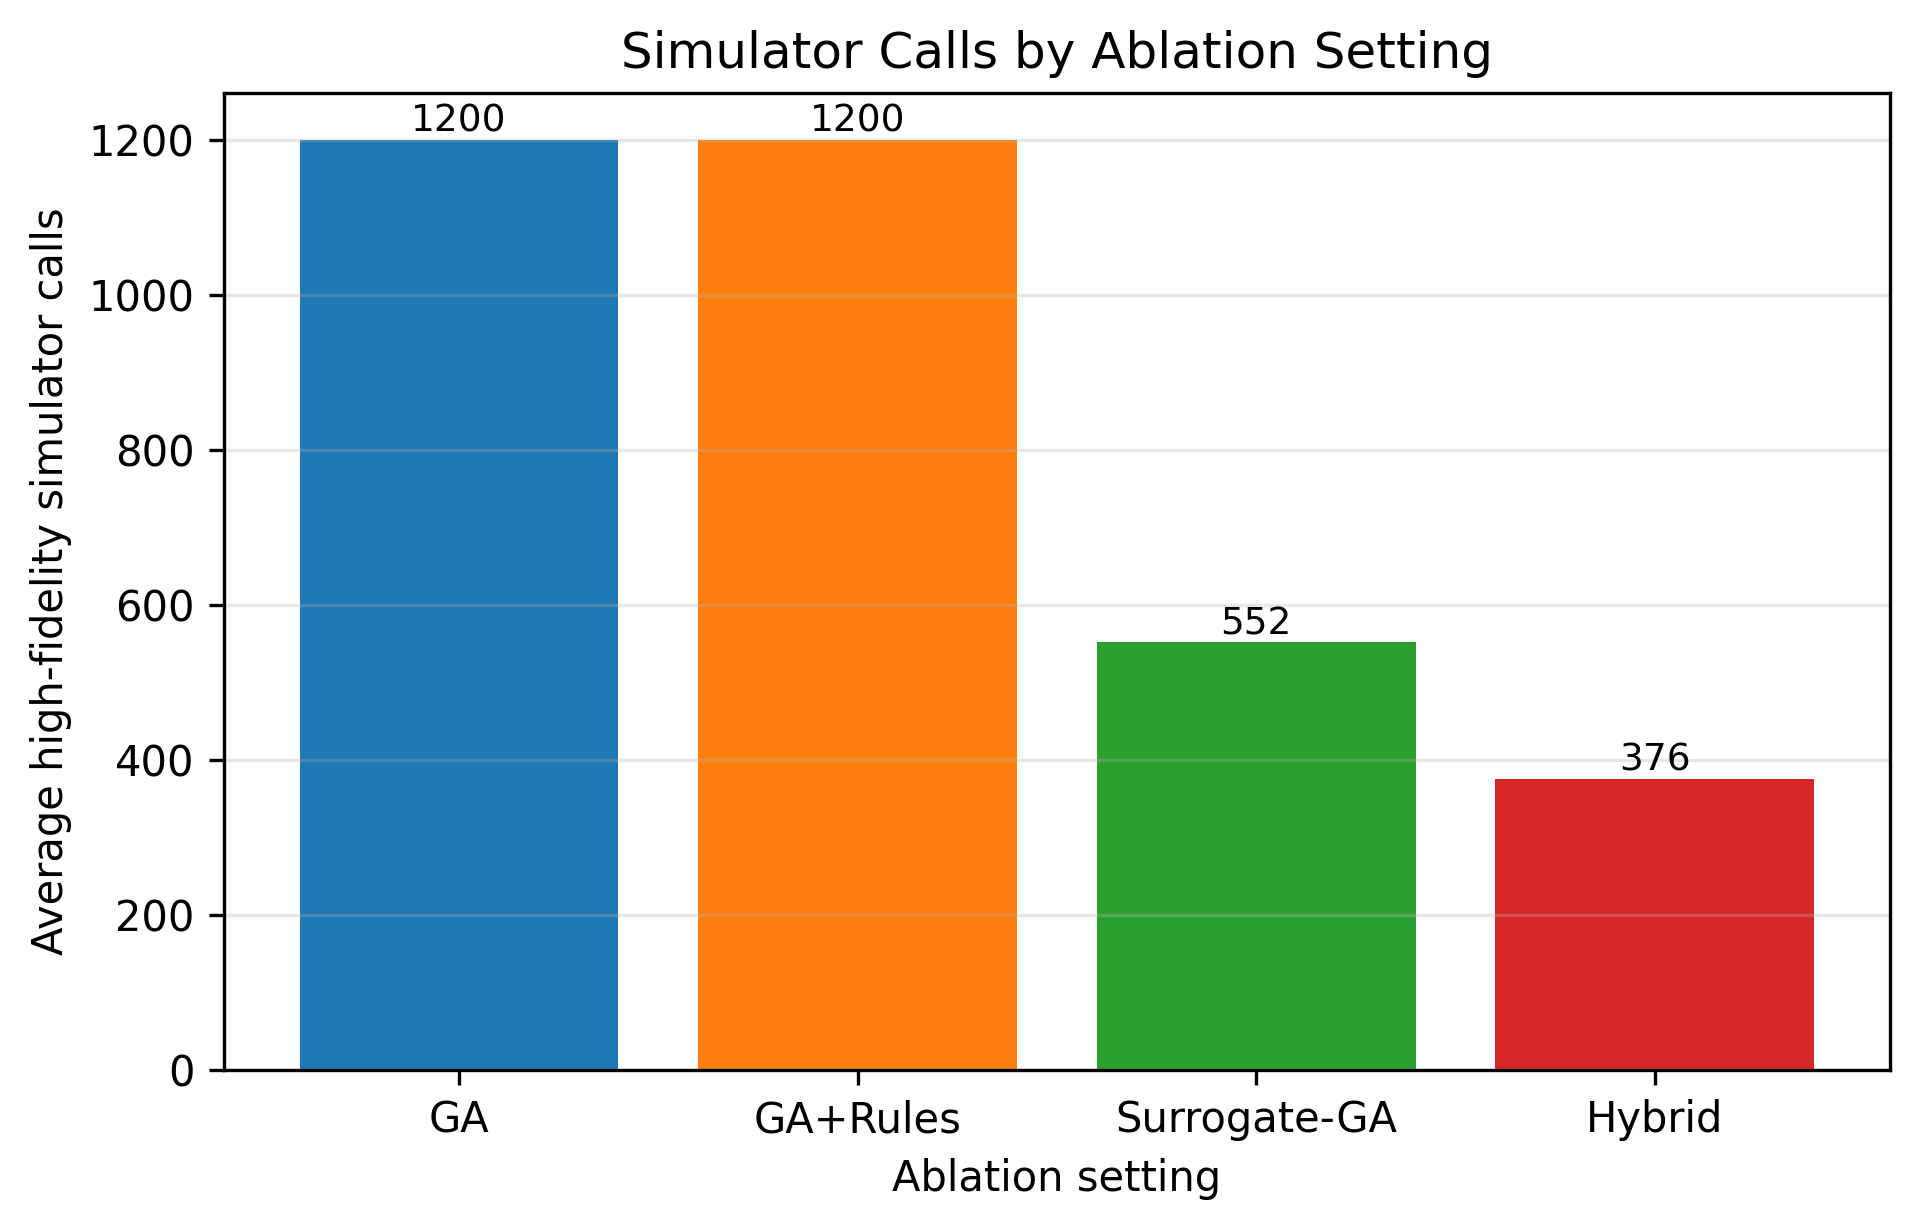

[OK] Saved: figures/ablation_simulator_calls.pdf


In [ ]:
# CELL 6 - Figure: Average simulator calls by ablation setting

plot_df = avg_ablation.copy()
methods = plot_df["MethodLabel"].astype(str).tolist()

plt.figure(figsize=(6.5, 4.2), dpi=300)
bars = plt.bar(
    methods,
    plot_df["SimCalls_mean"],
    color=[COLORS[m] for m in methods]
)

for bar, value in zip(bars, plot_df["SimCalls_mean"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylabel("Average high-fidelity simulator calls")
plt.xlabel("Ablation setting")
plt.title("Simulator Calls by Ablation Setting")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_simulator_calls.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("[OK] Saved:", out)


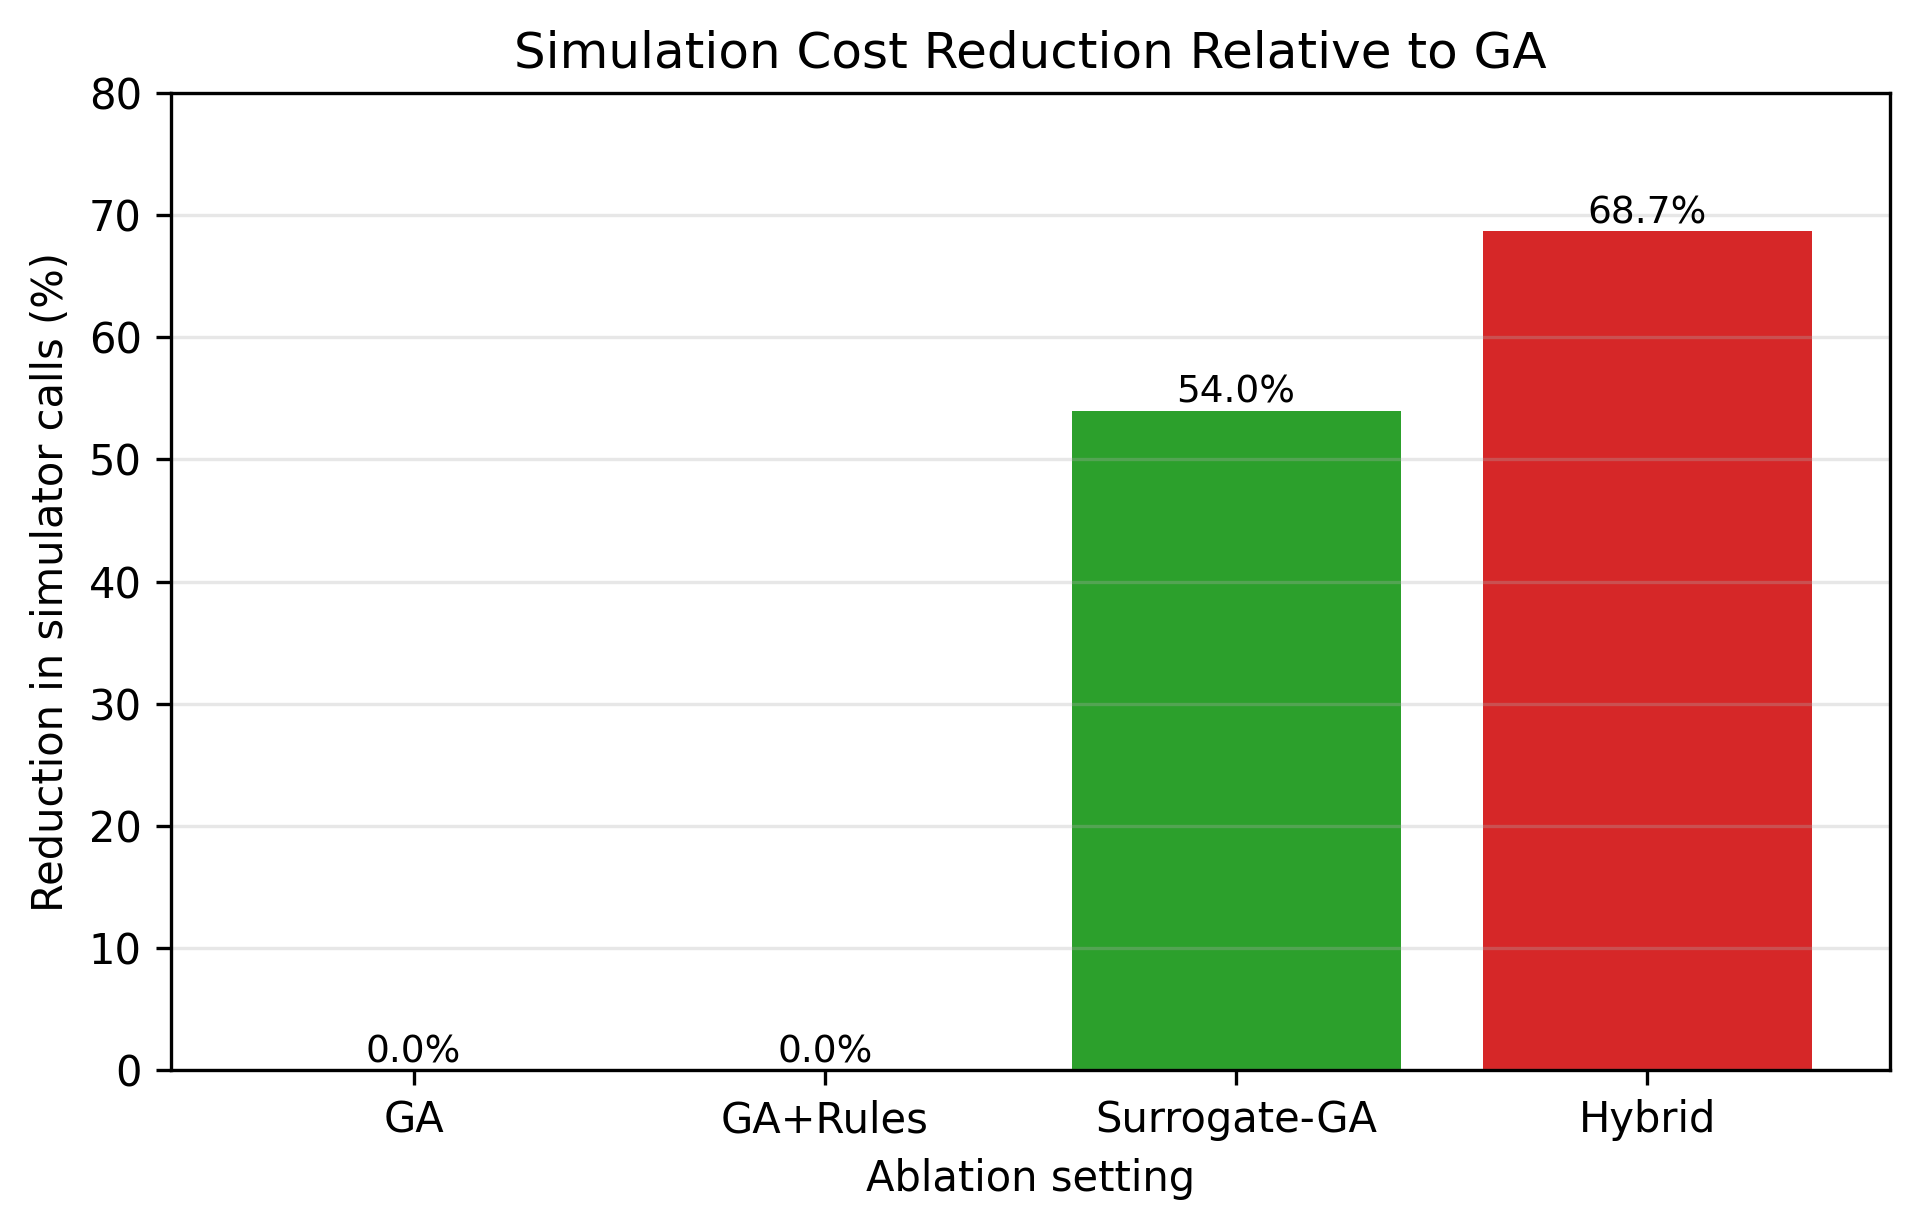

[OK] Saved: figures/ablation_reduction_vs_ga.pdf


In [ ]:
# CELL 7 - Figure: Reduction in simulator calls vs GA

plt.figure(figsize=(6.5, 4.2), dpi=300)
bars = plt.bar(
    methods,
    plot_df["Reduction_vs_GA_percent"],
    color=[COLORS[m] for m in methods]
)

for bar, value in zip(bars, plot_df["Reduction_vs_GA_percent"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylabel("Reduction in simulator calls (%)")
plt.xlabel("Ablation setting")
plt.title("Simulation Cost Reduction Relative to GA")
plt.ylim(0, max(80, plot_df["Reduction_vs_GA_percent"].max() + 10))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_reduction_vs_ga.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("[OK] Saved:", out)


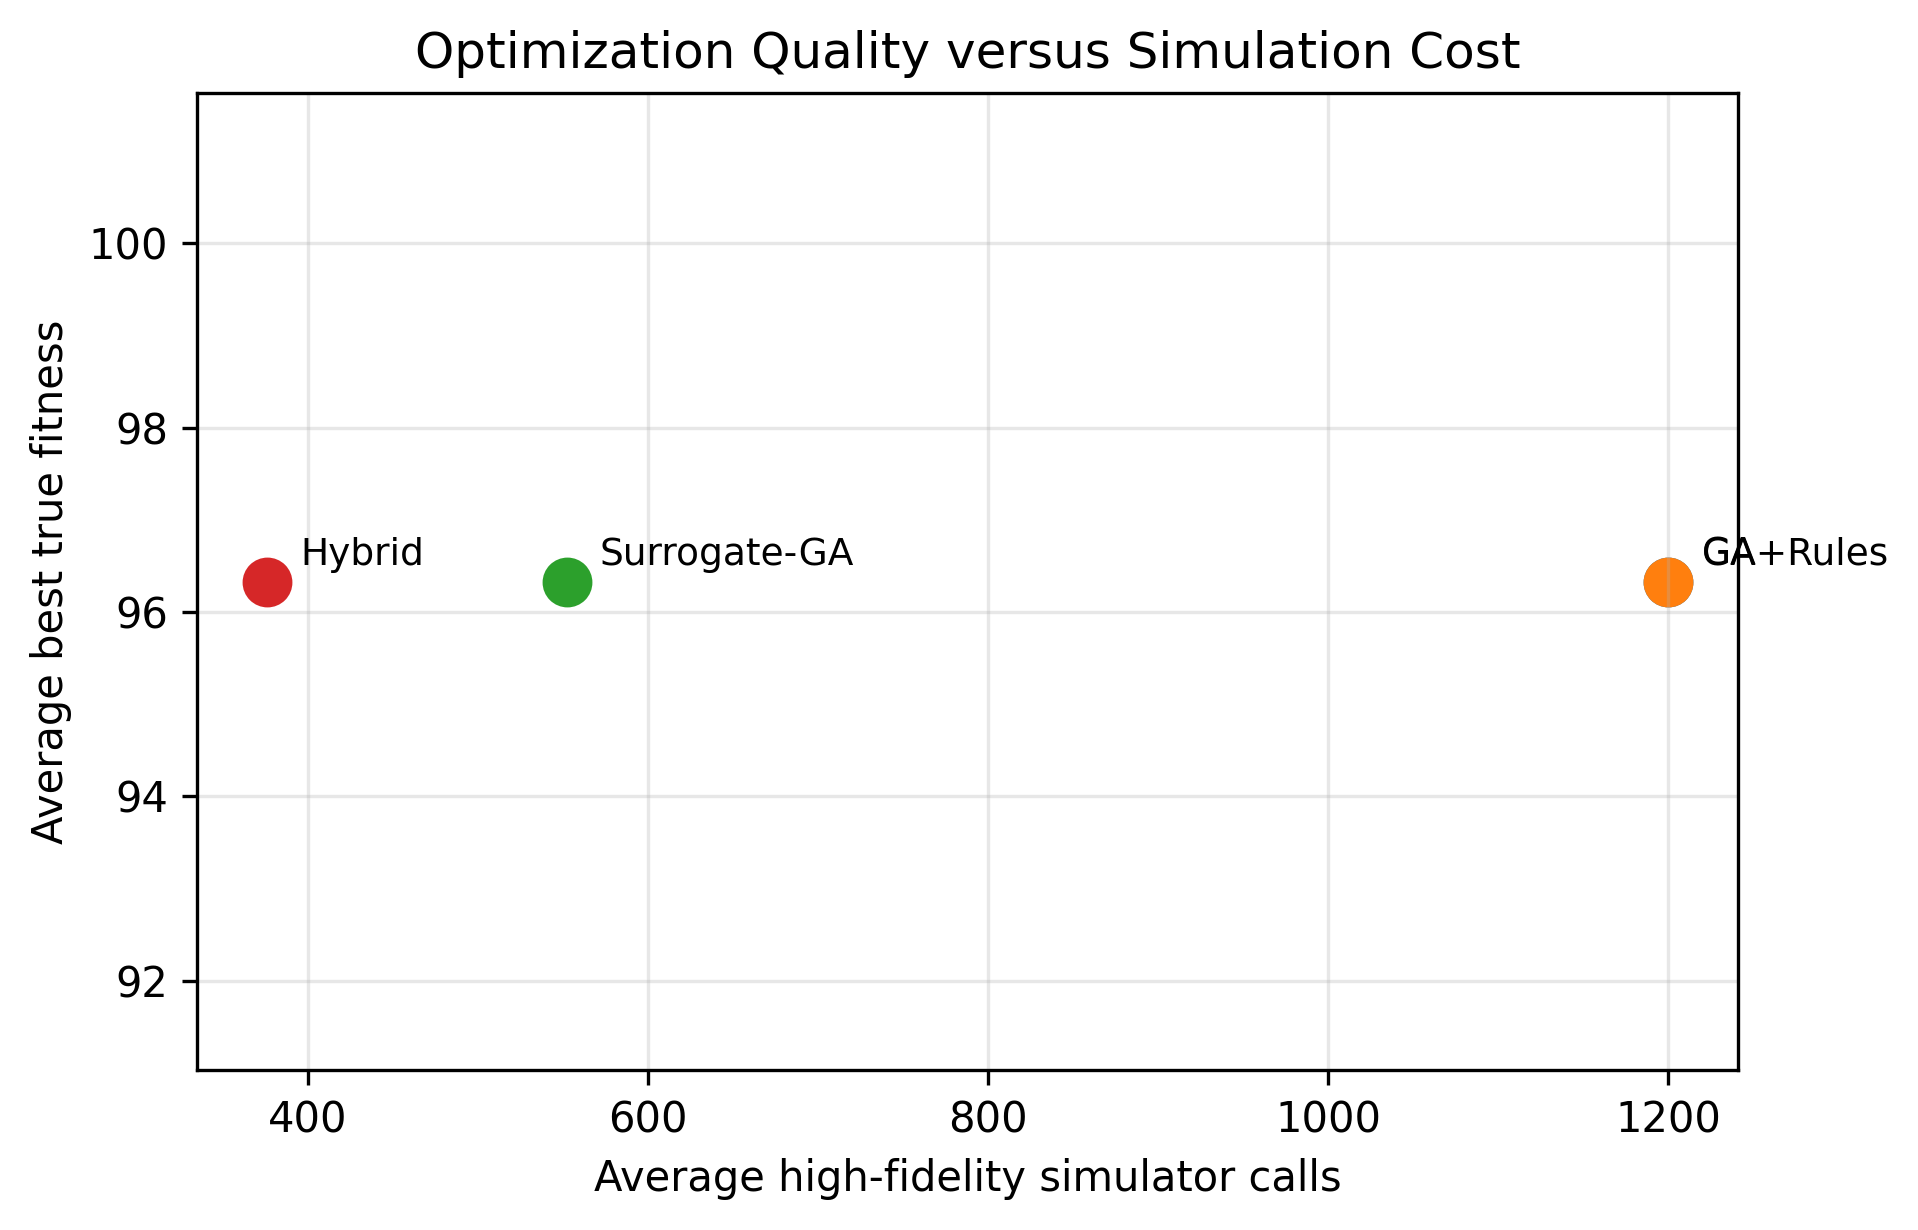

[OK] Saved: figures/ablation_cost_quality_tradeoff.pdf


In [ ]:
# CELL 8 - Figure: Cost-quality trade-off

plt.figure(figsize=(6.5, 4.2), dpi=300)

for _, row in plot_df.iterrows():
    method = str(row["MethodLabel"])
    plt.scatter(
        row["SimCalls_mean"],
        row["Fitness_mean"],
        s=120,
        color=COLORS[method],
        label=method
    )
    plt.annotate(
        method,
        (row["SimCalls_mean"], row["Fitness_mean"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9
    )

plt.xlabel("Average high-fidelity simulator calls")
plt.ylabel("Average best true fitness")
plt.title("Optimization Quality versus Simulation Cost")
plt.grid(alpha=0.3)
plt.tight_layout()

out = "figures/ablation_cost_quality_tradeoff.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("[OK] Saved:", out)


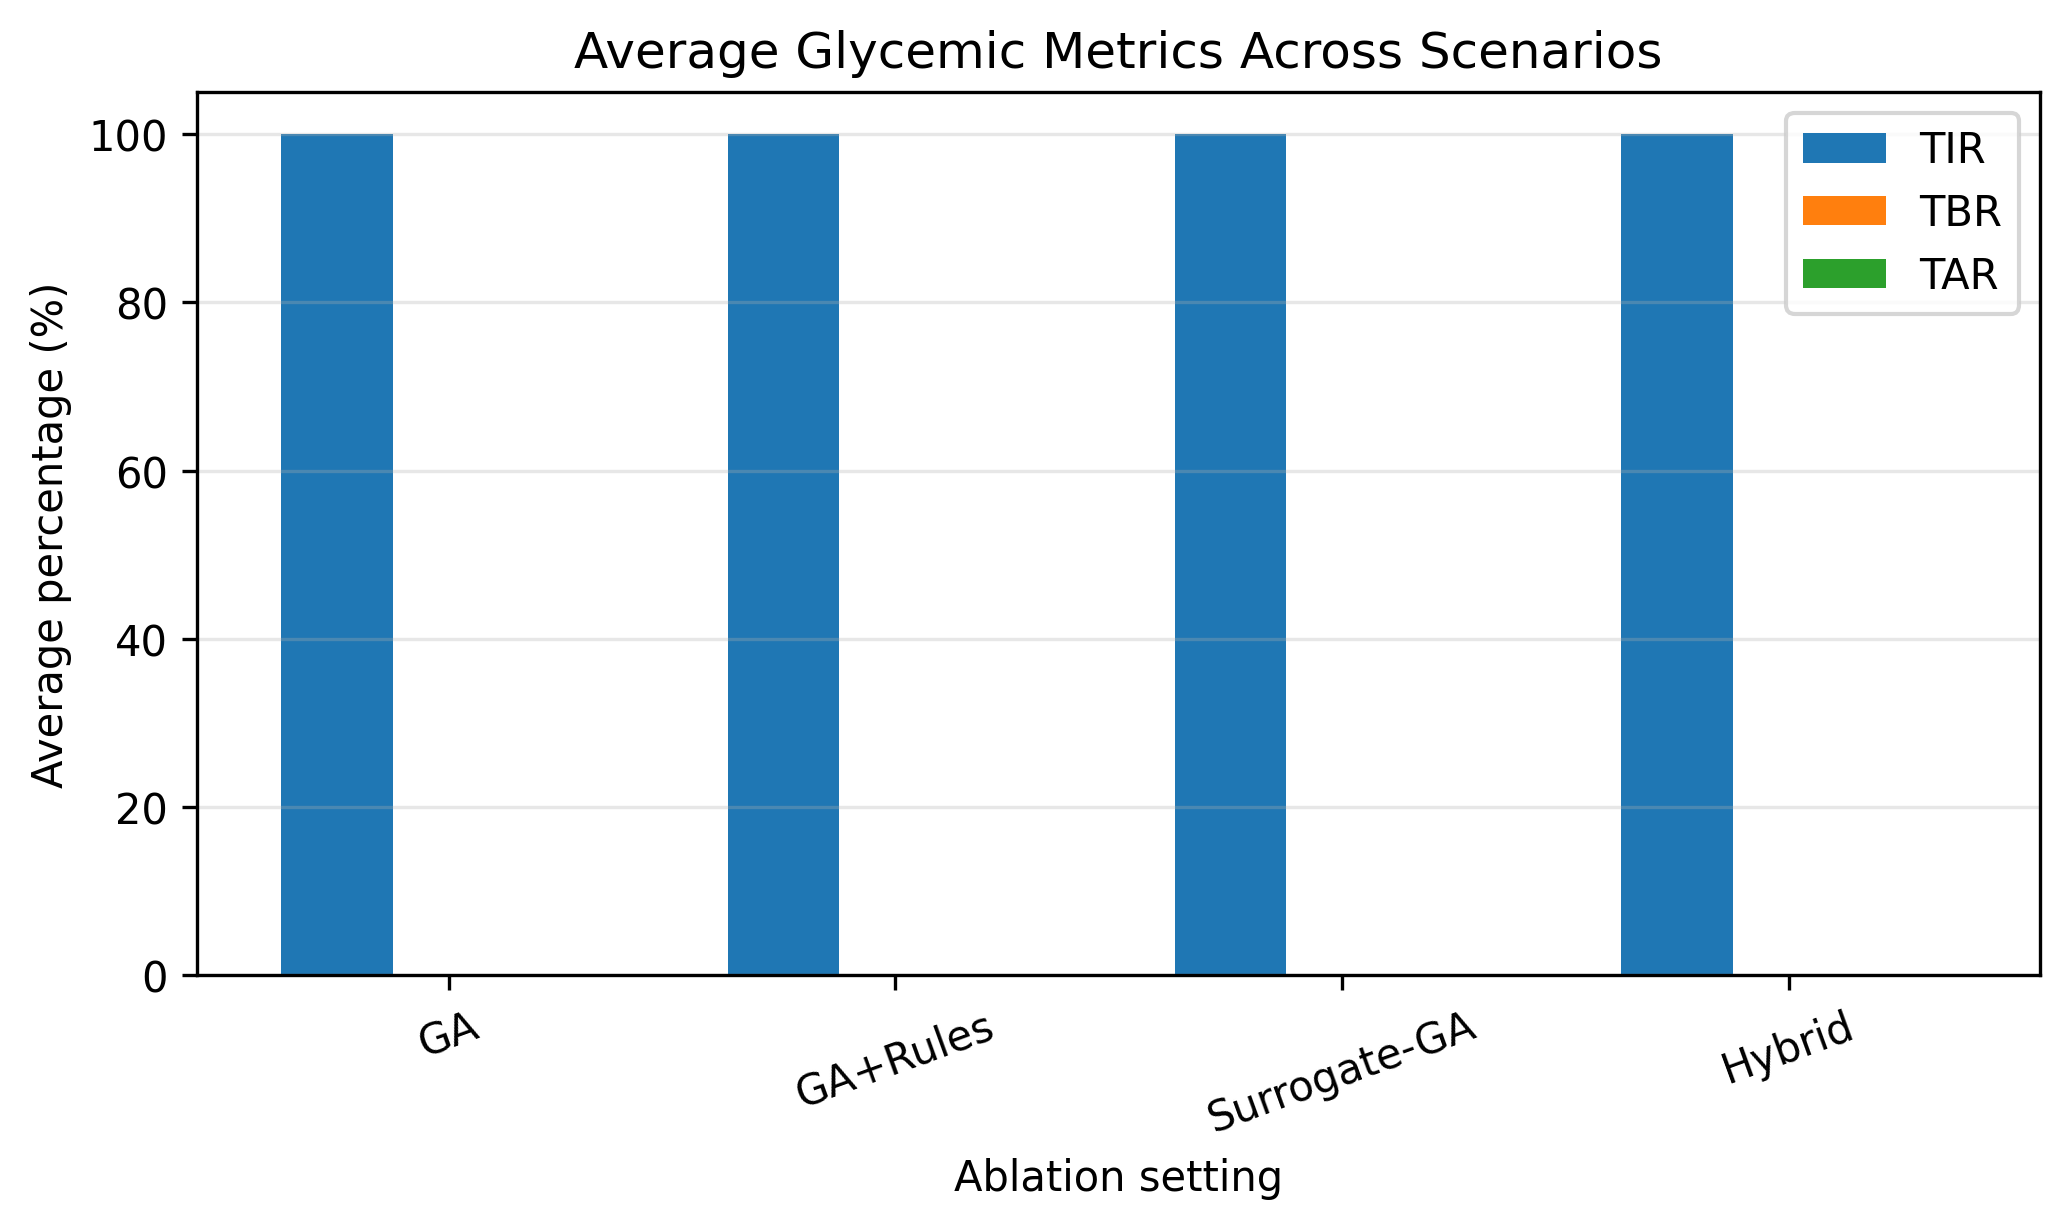

[OK] Saved: figures/ablation_glycemic_metrics.pdf


In [ ]:
# CELL 9 - Figure: TIR and safety metrics across ablation settings

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(7.0, 4.2), dpi=300)
plt.bar(x - width, plot_df["TIR_mean"], width, label="TIR")
plt.bar(x, plot_df["TBR_mean"], width, label="TBR")
plt.bar(x + width, plot_df["TAR_mean"], width, label="TAR")

plt.xticks(x, methods, rotation=20)
plt.ylabel("Average percentage (%)")
plt.xlabel("Ablation setting")
plt.title("Average Glycemic Metrics Across Scenarios")
plt.legend(frameon=True)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_glycemic_metrics.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("[OK] Saved:", out)


In [ ]:
# CELL 10 - LaTeX table for manuscript/supplementary material

paper_ablation = avg_ablation[[
    "MethodLabel",
    "Fitness_mean",
    "TIR_mean",
    "TBR_mean",
    "TAR_mean",
    "AUCregret_mean",
    "SimCalls_mean",
    "Reduction_vs_GA_percent"
]].copy()

paper_ablation.columns = [
    "Method",
    "Fitness",
    "TIR",
    "TBR",
    "TAR",
    "AUCregret",
    "SimCalls",
    "ReductionPct"
]

for col in ["Fitness", "TIR", "TBR", "TAR", "AUCregret", "SimCalls", "ReductionPct"]:
    paper_ablation[col] = paper_ablation[col].astype(float).round(2)

display(paper_ablation)

latex_table = paper_ablation.to_latex(
    index=False,
    escape=False,
    caption="Ablation study of the proposed hybrid optimization components.",
    label="tab:ablation_study"
)

print(latex_table)

with open("outputs/results/ablation_table_latex.tex", "w") as f:
    f.write(latex_table)

print("[OK] Saved: outputs/results/ablation_table_latex.tex")


,Method,Fitness,TIR,TBR,TAR,AUCregret,SimCalls,ReductionPct
0,GA,96.33,100.0,0.0,0.0,0.37,1200.0,0.00
1,GA+Rules,96.33,100.0,0.0,0.0,1.45,1200.0,0.00
2,Surrogate-GA,96.33,100.0,0.0,0.0,0.62,552.0,54.00
3,Hybrid,96.33,100.0,0.0,0.0,1.56,376.0,68.67


\begin{table}
\caption{Ablation study of the proposed hybrid optimization components.}
\label{tab:ablation_study}
\begin{tabular}{lrrrrrrr}
\toprule
Method & Fitness & TIR & TBR & TAR & AUCregret & SimCalls & ReductionPct \\
\midrule
GA & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 0.370000 & 1200.000000 & 0.000000 \\
GA+Rules & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 1.450000 & 1200.000000 & 0.000000 \\
Surrogate-GA & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 0.620000 & 552.000000 & 54.000000 \\
Hybrid & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 1.560000 & 376.000000 & 68.670000 \\
\bottomrule
\end{tabular}
\end{table}

[OK] Saved: outputs/results/ablation_table_latex.tex


## Interpretation for the manuscript

Use the following interpretation only if the generated values match the final results:

- `GA` provides the baseline optimization quality but requires the full simulator budget.
- `GA+Rules` isolates the contribution of safety-aware penalization.
- `Surrogate-GA` reduces simulator calls by replacing part of the true evaluations with surrogate predictions.
- `Hybrid` combines safety-aware evaluation and surrogate-assisted selective validation, giving the best cost reduction while preserving competitive optimization quality.

Suggested manuscript wording:

> The ablation analysis confirms that the simulation-cost reduction is mainly driven by surrogate-assisted selective evaluation, while the safety-aware component improves reliability by penalizing unsafe glucose excursions. The full Hybrid configuration achieves the strongest reduction in high-fidelity simulator calls while maintaining competitive optimization and glycemic regulation performance.
